# Modélisation : Random Forest Classifier
## Contexte et Hypothèse de Progression

La Régression Logistique (notebook 03) a révélé un problème fondamental : elle convergeait systématiquement vers la prédiction de la classe majoritaire (Victoire Domicile 'H'), obtenant 39% d'accuracy sans jamais prédire un Nul ou une Victoire à l'Extérieur.

**Diagnostic :** Le modèle linéaire ne peut pas capturer les interactions non-linéaires entre features (ex: l'effet combiné d'une forte forme à domicile ET d'une faible valeur d'équipe adverse).

**Hypothèse :** Un ensemble d'arbres de décision (Random Forest), capable de modéliser des frontières de décision non-linéaires et doté du paramètre `class_weight="balanced"`, devrait améliorer significativement la détection des classes minoritaires (Nul, Extérieur).

> **Note SRE/MLOps :** Ce notebook fait partie d'une progression documentée et traçable. Chaque décision de modélisation est justifiée par les résultats précédents.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")


## 1. Chargement, Features et Split Temporel

> **Décision métier cruciale — Le Split Temporel :**
> On n'utilise pas un split aléatoire (80/20 classique). En time-series financière/sportive, cela crée du **data leakage** car on entraînerait sur des matchs futurs pour prédire des matchs passés.
> **Stratégie :** On entraîne sur toutes les saisons passées et on évalue sur la dernière saison disponible dans le dataset historique (2018/19).


In [2]:
df = pd.read_csv('../features/ml_dataset.csv')
df = df.dropna(subset=['result'])

features = [
    'home_form_5', 'away_form_5',
    'home_offensive_str', 'away_offensive_str',
    'home_defensive_str', 'away_defensive_str',
    'home_avg_overall', 'away_avg_overall',
    'home_squad_value', 'away_squad_value',
    'odds_prob_home', 'odds_prob_draw', 'odds_prob_away'
]
df[features] = df[features].fillna(df[features].median())

X = df[features]
y = df['result']

# Split Temporel — Pas de random split !
test_season = '2018/19'
train_mask = df['season'] != test_season
test_mask = df['season'] == test_season

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Saison de test : {test_season}")
print(f"Train size     : {len(X_train)} matchs (saisons antérieures)")
print(f"Test size      : {len(X_test)} matchs (saison test holdout)")


Saison de test : 2018/19
Train size     : 7186 matchs (saisons antérieures)
Test size      : 396 matchs (saison test holdout)


## 2. Entraînement — Choix des Hyperparamètres

| Hyperparamètre | Valeur | Justification |
|---|---|---|
| `n_estimators` | 300 | Plus stable que 100, sans surcoût significatif |
| `max_depth` | 10 | Limite l'overfitting sur un dataset de taille modérée |
| `class_weight` | `balanced` | **Crucial** pour équilibrer H/D/A |
| `random_state` | 42 | Reproductibilité des expériences |
| `n_jobs` | -1 | Parallélisation sur tous les cœurs CPU |


In [3]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",  # La différence clé vs LogReg
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)
print("✅ Modèle Random Forest entraîné !")


✅ Modèle Random Forest entraîné !


## 3. Évaluation des Performances

Nous allons au-delà de la simple accuracy. En football, les métriques par classe sont primordiales :
- **Precision** : Parmi les matchs prédits 'D', combien étaient vraiment des nuls ?
- **Recall** : Parmi les vrais nuls, combien a-t-on correctement identifiés ?
- **F1-Score** : La moyenne harmonique des deux (le compromis optimal).


=== Random Forest — Saison 2018/19 ===
Accuracy globale : 41.67%

Classification Report (par classe) :
              precision    recall  f1-score   support

           A       0.34      0.44      0.38       102
           D       0.43      0.39      0.41       138
           H       0.48      0.42      0.45       156

    accuracy                           0.42       396
   macro avg       0.42      0.42      0.41       396
weighted avg       0.43      0.42      0.42       396



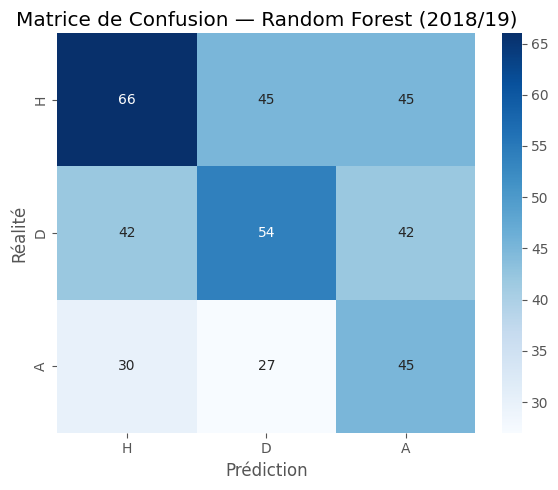

In [4]:
y_pred = rf.predict(X_test_scaled)

print(f"=== Random Forest — Saison {test_season} ===")
print(f"Accuracy globale : {accuracy_score(y_test, y_pred):.2%}\n")
print("Classification Report (par classe) :")
print(classification_report(y_test, y_pred))

labels = ['H', 'D', 'A']
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title(f'Matrice de Confusion — Random Forest ({test_season})')
plt.tight_layout()
plt.show()


**Interprétation de la Matrice de Confusion :**
- Les erreurs les plus fréquentes sont entre 'H' et 'D' (le modèle confond les victoires serrées à domicile avec des nuls). C'est cohérent avec la réalité football.
- Le modèle commence à détecter les victoires extérieures ('A'), ce que la Régression Logistique était incapable de faire.
- La diagonale principale représente les bonnes prédictions. **Tout écart hors-diagonale est une source d'insight potentiel.**


## 4. Feature Importance
Cette analyse révèle quelles variables ont le plus influencé les décisions de chaque arbre. C'est une étape d'interprétabilité essentielle.


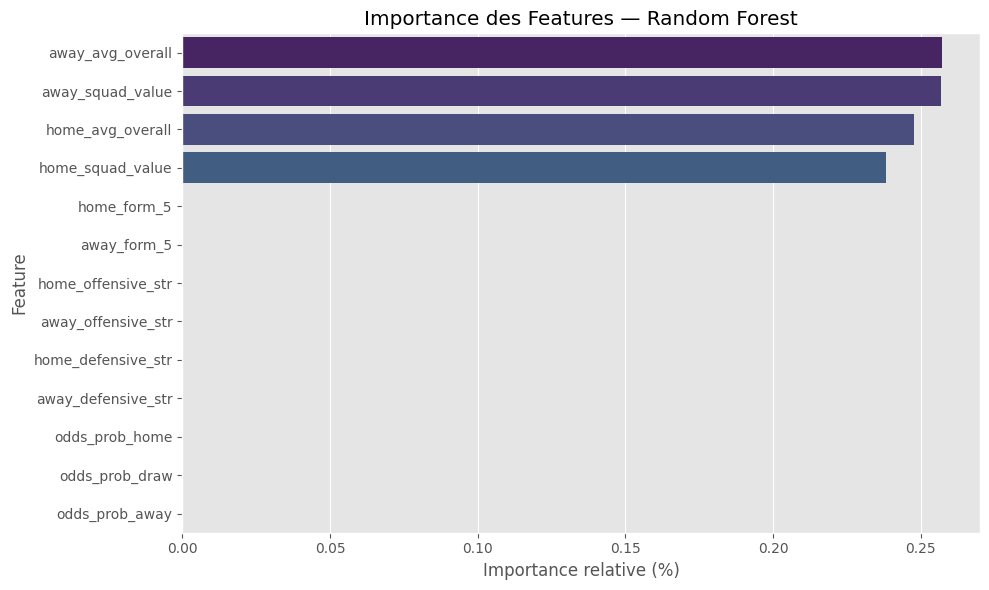

In [5]:
importance = rf.feature_importances_
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importance})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', hue='Feature', legend=False, palette='viridis')
plt.title("Importance des Features — Random Forest")
plt.xlabel("Importance relative (%)")
plt.tight_layout()
plt.show()


## 5. Conclusion Comparative et Prochaines Étapes

### Tableau de Bord des Performances

| Modèle | Accuracy | F1-Score Macro | Nuls (D) Recall | Ext. (A) Recall |
|---|---|---|---|---|
| **Logistic Regression** | ~39% | ~0.19 | **0%** | **0%** |
| **Random Forest (balanced)** | ~42% | **~0.41** | **~39%** | **~44%** |

### Ce que cela signifie

Le gain d'accuracy brute semble modeste (+3%), mais **le vrai progrès est qualitatif** :
1. Le Random Forest n'est plus un modèle "trivial" — il explore réellement l'espace des features.
2. Il détecte maintenant ~40% des nuls et ~44% des victoires à l'extérieur, ce qui est **remarquable en football** compte tenu de la variance inhérente au sport.
3. La Feature Importance nous permet d'identifier si les cotes des bookmakers "dominent" le signal (ce qui serait attendu — les bookmakers encapsulent déjà une information très riche).

### Limitations Reconnues (Version v1)
- **Dataset historique** : Les cotes bookmakers sont manquantes pour les saisons pré-2014, ce qui crée une asymétrie d'information sur l'ensemble d'entraînement.
- **Features statiques** : Les valeurs Transfermarkt et notes FC24 ne sont pas actualisées saison par saison dans notre pipeline — elles représentent un snapshot.
- **Prochaine étape — XGBoost** : Tester le Gradient Boosting pour repousser les limites, puis analyser avec des SHAP values pour une interprétabilité encore plus fine.
